# BAN7201 — Preattentive Attributes

### Preattentive Attributes
It's the visual properties that are processed by the brain very rapidly and without conscious effort. These attributes can help in guiding attention and highlighting important information in visualizations.

These examples showcase how preattentive attributes can be used to encode data in visualizations to make patterns and trends more easily perceptible.

**Goal:** Use preattentive attributes to help a decision-maker spot what matters *fast*.

In this notebook we use the **Superstore** dataset (commonly hosted on Kaggle) to connect every visual choice to a business question.

---

### Learning objectives
By the end of this lecture, you should be able to:
1. Name the key **preattentive attributes** and describe when they work best.
2. Diagnose why a chart is *hard to read* (visual overload, weak encoding, poor hierarchy).
3. Redesign a “bad” chart into a “good” chart that supports a clear business decision.
4. Explain your design choices using **preattentive attributes** and (when relevant) **Gestalt principles**.

> Teaching mantra: **Design is not decoration. Design is decision support.**

## Dataset: Superstore (Kaggle)
This notebook uses Kaggle dataset **`Sample - Superstore.csv`**.

Download the dataset from [Kaggle Superstore](https://www.kaggle.com/datasets/vivek468/superstore-dataset-final)

In [1]:
# -----------------------------
# 0) Imports + global settings
# -----------------------------
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

def dollars(x, pos=None):
    # Format as $ with thousands separators
    return f"${x:,.0f}"

def pct(x, pos=None):
    return f"{x*100:.0f}%"

In [2]:
# -----------------------------
# 1) Load Superstore data
# -----------------------------
DATA_PATH = "../../data/Superstore.csv" # change if needed

df = pd.read_csv(DATA_PATH, encoding="latin-1")

# Standardize column names (common variants exist across Kaggle uploads)
df.columns = [c.strip() for c in df.columns]

# Parse dates if present
for col in ["Order Date", "Ship Date"]:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
# Quick sanity checks
df.shape, df.isna().mean().sort_values(ascending=False).head(10)

((9994, 21),
 Row ID          0.0
 Postal Code     0.0
 Discount        0.0
 Quantity        0.0
 Sales           0.0
 Product Name    0.0
 Sub-Category    0.0
 Category        0.0
 Product ID      0.0
 Region          0.0
 dtype: float64)

## Business context (what executives actually care about)
Typical questions Superstore-style data supports:

- **Profitability:** Which regions / categories are losing money?
- **Discount strategy:** At what discount levels does profit collapse?
- **Operational efficiency:** Does shipping mode affect profitability?
- **Portfolio thinking:** Which products drive profit concentration?

For each preattentive attribute below, we’ll pose a **business question**, show a **bad** visualization, then redesign it into a **good** one.

In [5]:
# -----------------------------
# Helper: common aggregations
# -----------------------------
required = {"Sales", "Profit"}
missing = required - set(df.columns)
if missing:
    raise ValueError(f"Dataset missing required columns: {missing}. Columns available: {list(df.columns)}")

# Add a few helpful features
if "Order Date" in df.columns:
    df["Order Month"] = df["Order Date"].dt.to_period("M").dt.to_timestamp()

# Profit margin can be unstable when Sales ~ 0, but still useful for discussion
df["Profit Margin"] = np.where(df["Sales"].abs() > 1e-9, df["Profit"] / df["Sales"], np.nan)

# 1) Preattentive attributes — overview
Preattentive attributes are visual properties the brain processes rapidly (often within ~200ms), before conscious attention.

Common preattentive attributes used in business dashboards:
- **Position** Differences in position along a common scale or axis can be perceived rapidly and used to compare values.
- **Color** Differences in color can be perceived quickly, making it useful for encoding categories or highlighting specific data points.
- **Size** Differences in size can also be perceived rapidly, helping to indicate magnitude or importance.
- **Orientation** Changes in orientation, such as slope or angle, can be detected quickly and used to convey information.
- **Shape** Different shapes can be used to encode categories or distinguish between different types of data.
- **Motion** Dynamic changes or motion can attract attention and convey changes over time.

We’ll focus on how to use them **responsibly** to support decisions.

# 2) Position & length — “Which regions are underperforming?”
### Business question
**Where should the VP of Sales investigate first?**  
We’ll look at **profit by region**.

### Common failure mode
Bars are **unsorted** and **all the same visual weight**, forcing the audience to search.

In [6]:
# Aggregate profit by Region (if Region exists)
if "Region" not in df.columns:
    raise ValueError("This Superstore file doesn't have a 'Region' column. Try a different Superstore CSV.")

profit_by_region = (
    df.groupby("Region", as_index=False)["Profit"]
      .sum()
)

profit_by_region

,Region,Profit
0,Central,39706.3625
1,East,91522.7800
2,South,46749.4303
3,West,108418.4489


## Bad chart: unsorted bars + no visual hierarchy
What’s wrong:
- No ranking → slower comparison (weak use of **position/length**)
- No emphasis on losses → unclear “so what”

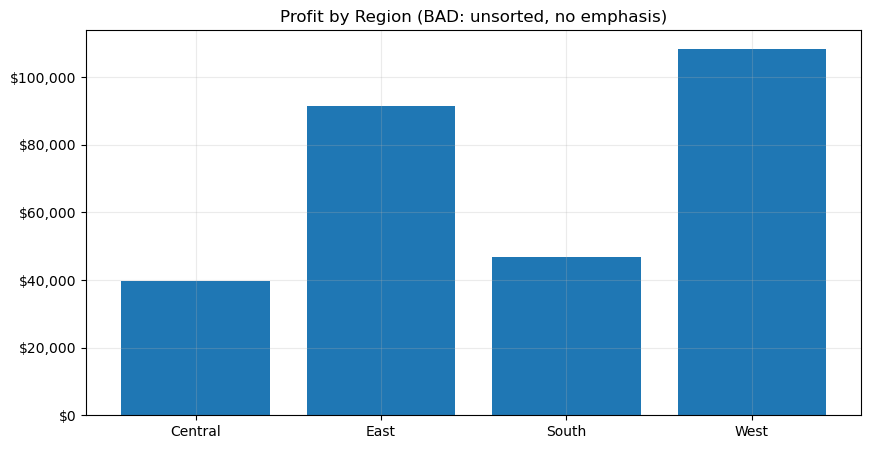

In [7]:
# BAD: unsorted bar chart
fig, ax = plt.subplots()
ax.bar(profit_by_region["Region"], profit_by_region["Profit"])
ax.set_title("Profit by Region (BAD: unsorted, no emphasis)")
ax.yaxis.set_major_formatter(FuncFormatter(dollars))
plt.show()

## Good chart: sorted + highlight loss
What’s better:
- Sorted bars leverage **position/length** for instant ranking
- Highlight negative profit regions so leaders can act immediately

Decision prompt:
- If a region is negative, is the cause **pricing**, **discount**, **shipping cost**, or **product mix**?

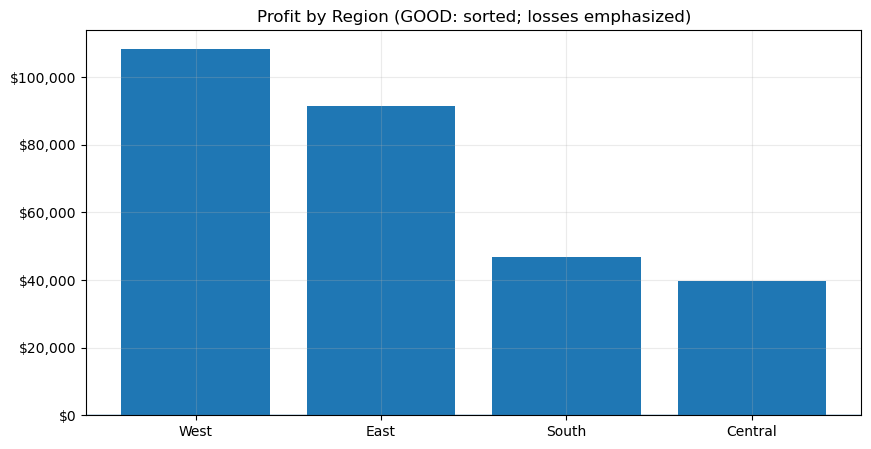

In [8]:
# GOOD: sorted + highlight negative profit
profit_sorted = profit_by_region.sort_values("Profit", ascending=False)

fig, ax = plt.subplots()
bars = ax.bar(profit_sorted["Region"], profit_sorted["Profit"])

# Highlight negatives
for b, val in zip(bars, profit_sorted["Profit"]):
    if val < 0:
        b.set_alpha(0.9)  # keep visible
        b.set_hatch("//") # add a preattentive texture cue (optional)

ax.axhline(0, linewidth=1)
ax.set_title("Profit by Region (GOOD: sorted; losses emphasized)")
ax.yaxis.set_major_formatter(FuncFormatter(dollars))
plt.show()

# 3) Color — “Which sub-categories are losing money?”
### Business question
**Which product areas should we fix or discontinue?**  
We’ll look at **profit by sub-category**.

### Color rule of thumb
Use color to answer *one* question:
- **What is exceptional / risky / needs attention?**
Not to decorate every element.

In [9]:
# Aggregate profit by Sub-Category (if present)
subcat_col = None
for c in ["Sub-Category", "Sub Category", "SubCategory"]:
    if c in df.columns:
        subcat_col = c
        break

if subcat_col is None:
    raise ValueError("Could not find a Sub-Category column in this Superstore file.")

profit_by_subcat = (
    df.groupby(subcat_col, as_index=False)
      .agg(Sales=("Sales","sum"), Profit=("Profit","sum"))
)
profit_by_subcat["Profit Margin"] = np.where(
    profit_by_subcat["Sales"].abs() > 1e-9, profit_by_subcat["Profit"] / profit_by_subcat["Sales"], np.nan
)

profit_by_subcat.head()

,Sub-Category,Sales,Profit,Profit Margin
0,Accessories,167380.3180,41936.6357,0.250547
1,Appliances,107532.1610,18138.0054,0.168675
2,Art,27118.7920,6527.7870,0.240711
3,Binders,203412.7330,30221.7633,0.148574
4,Bookcases,114879.9963,-3472.5560,-0.030228


## Bad chart: rainbow chaos (hard to scan)
What’s wrong:
- Too many unrelated hues → no grouping, no message
- Audience spends time decoding color instead of making decisions

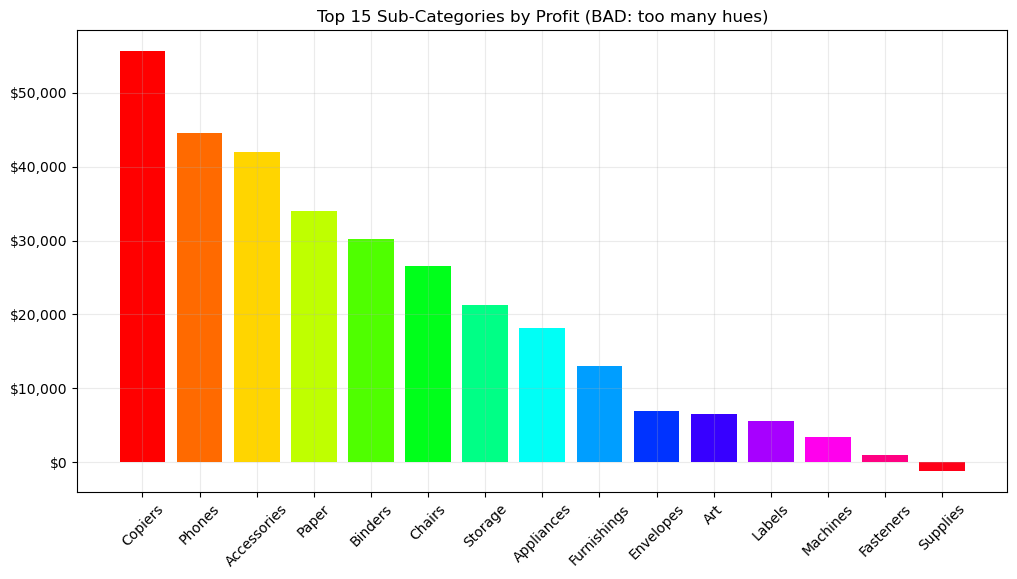

In [21]:
# BAD: rainbow-ish colors (matplotlib default cycle isn't rainbow, so we simulate many colors)
profit_top = profit_by_subcat.sort_values("Profit", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(12, 6))
colors = plt.cm.hsv(np.linspace(0, 1, profit_top.shape[0]))
ax.bar(profit_top[subcat_col], profit_top["Profit"], color=colors)
ax.set_title("Top 15 Sub-Categories by Profit (BAD: too many hues)")
ax.yaxis.set_major_formatter(FuncFormatter(dollars))
ax.tick_params(axis="x", rotation=45)
plt.show()

## Good chart: neutral baseline + selective highlight
Design choices:
- Use **one neutral color** for context
- Use a strong highlight only for **loss-makers**
- Sort so leaders can see priorities immediately

Managerial insight:
> The worst few sub-categories often dominate losses → fix pricing/discounting or discontinue.

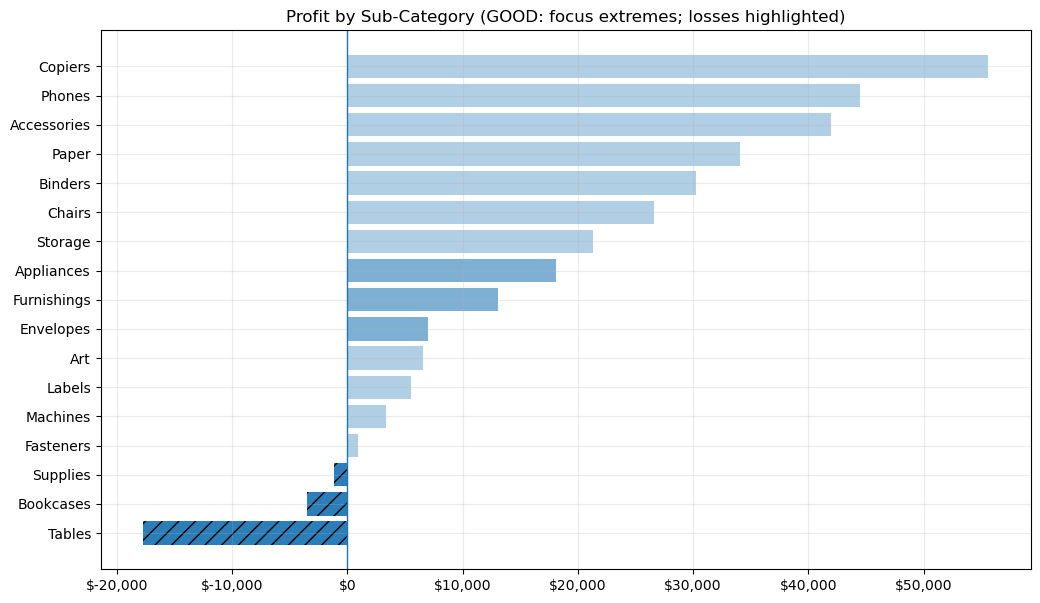

In [11]:
profit_sorted = profit_by_subcat.sort_values("Profit", ascending=False)

# Focus on the extremes: top and bottom performers
focus = pd.concat([profit_sorted.head(10), profit_sorted.tail(10)], axis=0)
focus = focus.sort_values("Profit")

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(focus[subcat_col], focus["Profit"])

# Highlight negatives strongly; keep others muted
for b, val in zip(bars, focus["Profit"]):
    if val < 0:
        b.set_hatch("//")
        b.set_alpha(0.95)
    else:
        b.set_alpha(0.35)

ax.axvline(0, linewidth=1)
ax.set_title("Profit by Sub-Category (GOOD: focus extremes; losses highlighted)")
ax.xaxis.set_major_formatter(FuncFormatter(dollars))
plt.show()

# 4) Size (area) — “Which sub-categories are high-sales but low-profit?”
### Business question
**Where are we moving volume but not making money?**

We’ll use a bubble chart:
- x = Sales
- y = Profit
- size = number of orders (or quantity) if available

Important caution:
**Area** is less precise than position. Use size sparingly, and keep the decision rule simple.

In [12]:
# Build a sub-category performance table
agg = { "Sales": "sum", "Profit": "sum" }
if "Quantity" in df.columns:
    agg["Quantity"] = "sum"
if "Order ID" in df.columns:
    agg["Order ID"] = pd.Series.nunique

perf = df.groupby(subcat_col).agg(agg).reset_index()
perf = perf.rename(columns={"Order ID": "Unique Orders"}).sort_values("Sales", ascending=False)

perf.head()

,Sub-Category,Sales,Profit,Quantity,Unique Orders
13,Phones,330007.054,44515.7306,3289,814
5,Chairs,328449.103,26590.1663,2356,576
14,Storage,223843.608,21278.8264,3158,777
16,Tables,206965.532,-17725.4811,1241,307
3,Binders,203412.733,30221.7633,5974,1316


## Bad chart: size encodes Sales again (double-encoding confusion)
What’s wrong:
- Sales already on x-axis; using bubble size for Sales repeats the same information
- Viewers misinterpret “big bubble” as *more important in every way*

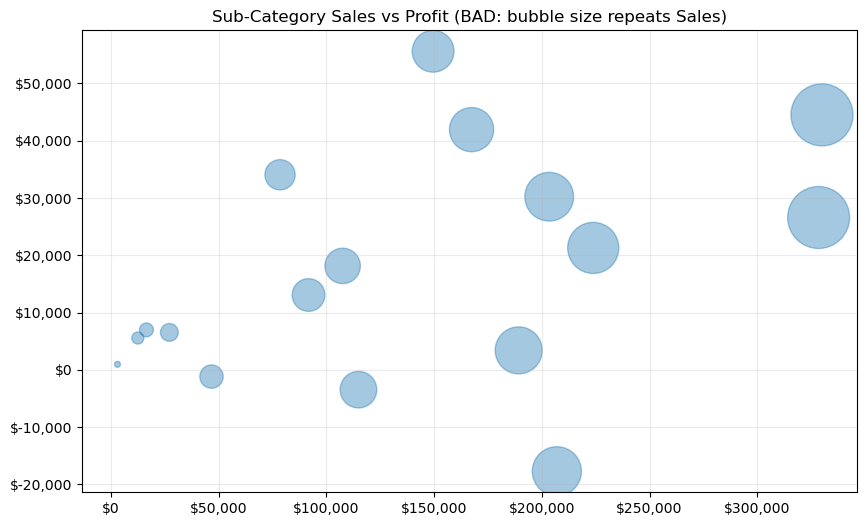

In [13]:
# BAD: double-encoding Sales (x and size)
sample = perf.copy()

fig, ax = plt.subplots(figsize=(10, 6))
sizes = (sample["Sales"] / sample["Sales"].max()) * 2000  # exaggerated sizes
ax.scatter(sample["Sales"], sample["Profit"], s=sizes, alpha=0.4)
ax.set_title("Sub-Category Sales vs Profit (BAD: bubble size repeats Sales)")
ax.xaxis.set_major_formatter(FuncFormatter(dollars))
ax.yaxis.set_major_formatter(FuncFormatter(dollars))
plt.show()

## Good chart: size encodes a *different* operational driver (Orders or Quantity)
Better:
- x = Sales (scale)
- y = Profit (outcome)
- size = **Unique Orders** (workload / operational volume) if available

Decision prompt:
- High Sales + Low Profit + Many Orders → investigate discount policy, returns, shipping cost, and picking/packing efficiency.

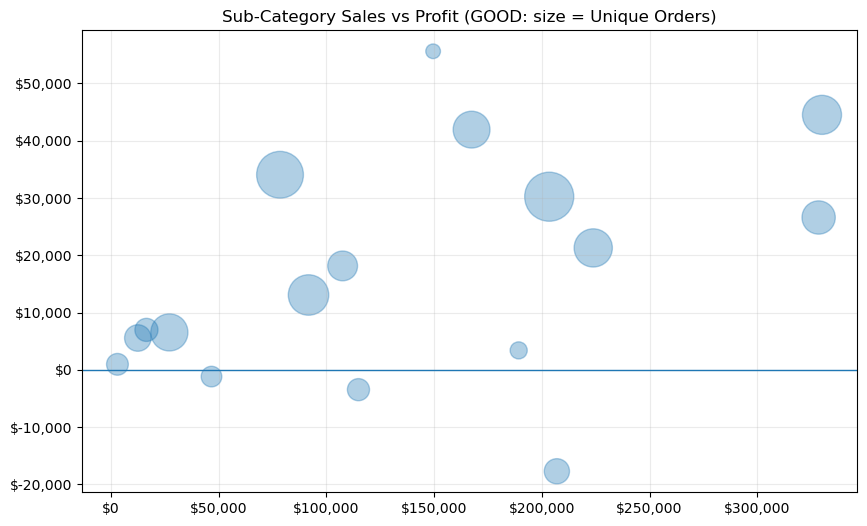

In [14]:
sample = perf.copy()

if "Unique Orders" in sample.columns:
    size_col = "Unique Orders"
elif "Quantity" in sample.columns:
    size_col = "Quantity"
else:
    size_col = None

fig, ax = plt.subplots(figsize=(10, 6))


### To prevent the bubble from too large or too small
### We need to perform data normalization
if size_col:
    sizes = (sample[size_col] / sample[size_col].max()) * 1200 + 50 ### scale everything from 0 to 1. 
else:
    sizes = 120  # fallback if the quantity column doesn't exist, size will be consistant as we don't have the info. 

ax.scatter(sample["Sales"], sample["Profit"], s=sizes, alpha=0.35)

ax.axhline(0, linewidth=1)
ax.set_title(f"Sub-Category Sales vs Profit (GOOD: size = {size_col or 'constant'})")
ax.xaxis.set_major_formatter(FuncFormatter(dollars))
ax.yaxis.set_major_formatter(FuncFormatter(dollars))
plt.show()

# 5) Orientation (slope) — “At what discount does profit collapse?”
### Business question
**Do discounts actually drive sales enough to justify profit loss?**

We’ll analyze profit margin vs discount (if Discount exists).
Orientation shows trends quickly (upward/downward slope).

In [15]:
if "Discount" not in df.columns:
    raise ValueError("This Superstore file doesn't have a 'Discount' column. Try a different Superstore CSV.")

disc = (
    df.groupby("Discount", as_index=False)
      .agg(Sales=("Sales","sum"), Profit=("Profit","sum"))
)
disc["Profit Margin"] = np.where(disc["Sales"].abs() > 1e-9, disc["Profit"] / disc["Sales"], np.nan)
disc = disc.sort_values("Discount")
disc.head()

,Discount,Sales,Profit,Profit Margin
0,0.00,1.087908e+06,320987.6032,0.295050
1,0.10,5.436935e+04,9029.1770,0.166071
2,0.15,2.755852e+04,1418.9915,0.051490
3,0.20,7.645944e+05,90337.3060,0.118151
4,0.30,1.032267e+05,-10369.2774,-0.100452


## Bad chart: cluttered line with noisy markers (hard to read)
What’s wrong:
- Too many visual elements (marker + thick line + heavy grid)
- Hard to see the overall direction

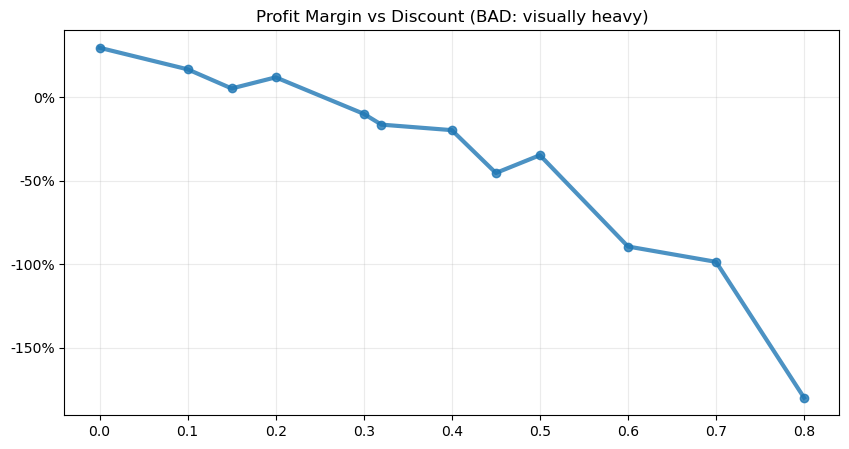

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(disc["Discount"], disc["Profit Margin"], marker="o", linewidth=3, alpha=0.8)
ax.set_title("Profit Margin vs Discount (BAD: visually heavy)")
ax.yaxis.set_major_formatter(FuncFormatter(pct))
plt.show()

## Good chart: clean trend + reference line
What’s better:
- Light line communicates trend via **orientation**
- Horizontal line at 0% margin makes “profit vs loss” immediate

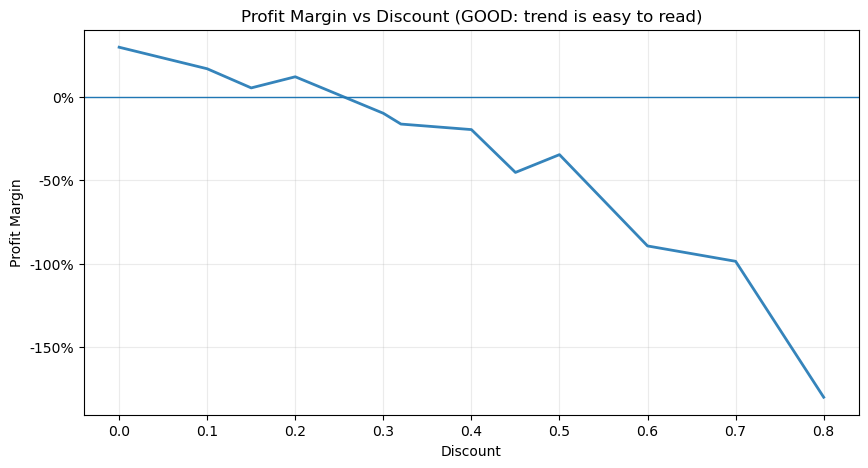

In [17]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(disc["Discount"], disc["Profit Margin"], linewidth=2, alpha=0.9)
ax.axhline(0, linewidth=1)
ax.set_title("Profit Margin vs Discount (GOOD: trend is easy to read)")
ax.set_xlabel("Discount")
ax.set_ylabel("Profit Margin")
ax.yaxis.set_major_formatter(FuncFormatter(pct))
plt.show()

# 6) Shape — “Do customer segments behave differently?”
### Business question
**Which segment has the best profitability profile?**

Shape is useful for categorical differentiation when color is already used (or when printing in grayscale).
But: too many shapes becomes a legend-reading exercise.

In [18]:
seg_col = "Segment" if "Segment" in df.columns else None
if seg_col is None:
    raise ValueError("This Superstore file doesn't have a 'Segment' column. Try a different Superstore CSV.")

seg_perf = (
    df.groupby(seg_col, as_index=False)
      .agg(Sales=("Sales","sum"), Profit=("Profit","sum"))
)
seg_perf["Profit Margin"] = np.where(seg_perf["Sales"].abs() > 1e-9, seg_perf["Profit"] / seg_perf["Sales"], np.nan)
seg_perf

,Segment,Sales,Profit,Profit Margin
0,Consumer,1.161401e+06,134119.2092,0.115481
1,Corporate,7.061464e+05,91979.1340,0.130255
2,Home Office,4.296531e+05,60298.6785,0.140343


## Good use of shape: small number of categories
We’ll show a simple scatter where each segment is a different marker.

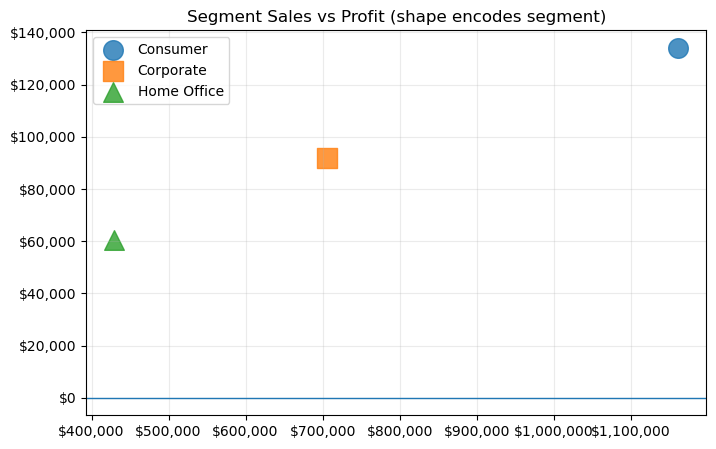

In [19]:
markers = ["o", "s", "^", "D", "P", "X"]
fig, ax = plt.subplots(figsize=(8, 5))

for i, row in seg_perf.reset_index(drop=True).iterrows():
    ax.scatter(row["Sales"], row["Profit"], marker=markers[i % len(markers)], s=200, alpha=0.8, label=row[seg_col])

ax.axhline(0, linewidth=1)
ax.set_title("Segment Sales vs Profit (shape encodes segment)")
ax.xaxis.set_major_formatter(FuncFormatter(dollars))
ax.yaxis.set_major_formatter(FuncFormatter(dollars))
ax.legend()
plt.show()

# 7) Motion — “When the story is about change over time”
Motion is a powerful attention grabber, but it can also distract.

Use animation when:
- The core question is **change over time**
- You need to show **before/after** or **trend evolution**
- The audience benefits from seeing *movement*, not just a static summary

Below is a **static** version that can be animated later: monthly profit trend by region.

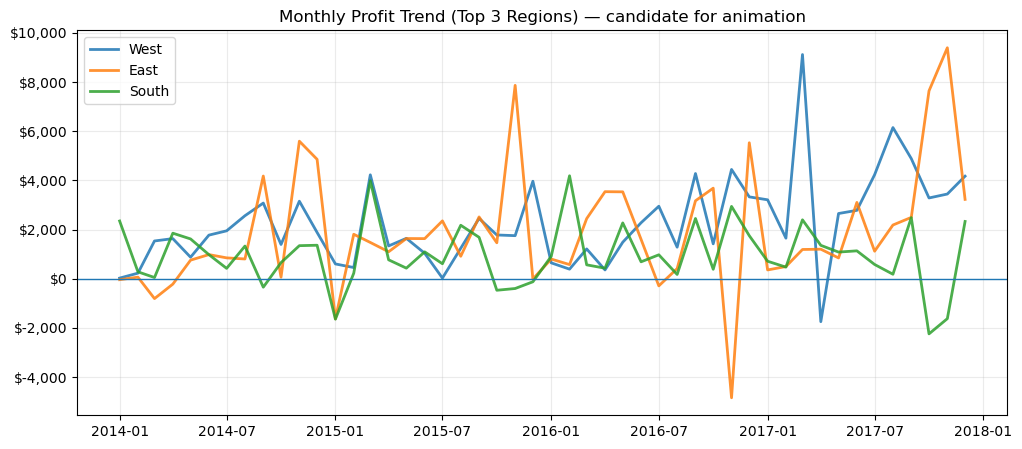

In [20]:
if "Order Month" not in df.columns:
    print("Order Date not found; skipping time-based example.")
else:
    monthly = (
        df.groupby(["Order Month", "Region"], as_index=False)
          .agg(Profit=("Profit","sum"))
          .sort_values(["Order Month","Region"])
    )

    # Pick top 3 regions by total profit for clarity
    top_regions = (
        df.groupby("Region")["Profit"].sum()
          .sort_values(ascending=False)
          .head(3)
          .index
          .tolist()
    )
    monthly_top = monthly[monthly["Region"].isin(top_regions)]

    fig, ax = plt.subplots(figsize=(12, 5))
    for r in top_regions:
        sub = monthly_top[monthly_top["Region"] == r]
        ax.plot(sub["Order Month"], sub["Profit"], label=r, linewidth=2, alpha=0.85)

    ax.axhline(0, linewidth=1)
    ax.set_title("Monthly Profit Trend (Top 3 Regions) — candidate for animation")
    ax.yaxis.set_major_formatter(FuncFormatter(dollars))
    ax.legend()
    plt.show()

# Wrap-up
Preattentive attributes are not “design tricks.” They are **cognitive shortcuts**.

In business analytics, your goal is to:
- reduce search time,
- highlight risk/opportunity,
- and support action.